# Unsupervised NN

### Model Character
input:
- distribution of d_k (sum = 1)
- |H_k|

output:
- list of b_k
- list of f_dt_k
- list of beta_k

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import numpy as np
import torch


if torch.backends.mps.is_available():
    device = 'mps'
    print("Success: Using Apple Silicon GPU acceleration.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("Success: Using Cuda GPU acceleration.")
else:
    device = 'cpu'
    print("Using CPU.")

Success: Using Apple Silicon GPU acceleration.


Read Data

In [11]:
from SymetricOptim import SymmetricResidualNet


K = 4
B_total = 100e3
C_DT_total = 50e6
beta_max = 3
model = SymmetricResidualNet(4, B_total, C_DT_total, beta_max)

In [12]:
from DataUtil import generate_data_loader


data_loader = generate_data_loader(300, 300, K, 16e3, 64)

In [ ]:
from TrainingUtil import unsupervised_loss, train
from torch.optim import Adam, lr_scheduler
from EarlyStopping import EarlyStopping


optimizer = Adam(model.parameters(), lr=0.001)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopper = EarlyStopping(patience=7, min_delta=0.5)
loss_fn = unsupervised_loss

train(model, data_loader, optimizer, scheduler, early_stopper, loss_fn, device, n_epoch=100)

start data job
finish data job
start training
epoch: 01, avg loss: 35.37724486935961
epoch: 02, avg loss: 34.560860222421304
epoch: 03, avg loss: 34.54055592008915
epoch: 04, avg loss: 34.55225752021882
epoch: 05, avg loss: 34.52670021165578
epoch: 06, avg loss: 34.521250718692215
epoch: 07, avg loss: 34.52433311608809
epoch: 08, avg loss: 34.515037760297375
epoch: 09, avg loss: 34.508335236886246
best epoch: 02, best avg loss: 34.560860


In [14]:
state_dict = torch.load('model/checkpoint.pth', map_location=device, weights_only=True)
model.to(device)
model.load_state_dict(state_dict)

<All keys matched successfully>

[14.378282  11.180302   6.84004    3.3065941]


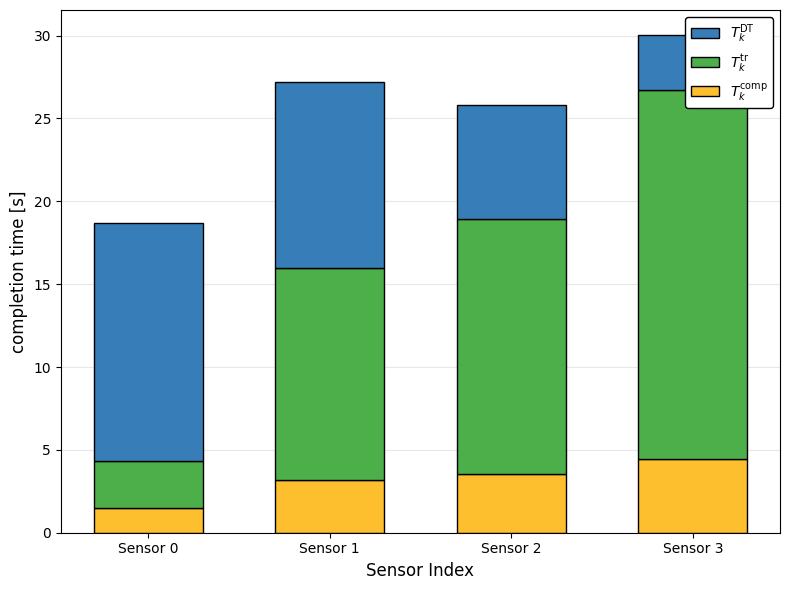

In [37]:
import TrainingUtil as tu
import DataUtil as du
import Plotting as pt
import ProcessTime as process

length=1000

H_k = du.generate_channel_gains(length, 4)


D_k = torch.tensor([[0.25, 0.75, 1.25, 1.75]]).repeat(length, 1) * 4e3
X_test = torch.cat((D_k, H_k), dim=1).to(device)
with torch.no_grad():
    model.eval()
    b, f, beta = model(X_test)
    pt.plot_result(process.t_comp(X_test, b, f, beta, numpy=True).mean(0), process.t_tr(X_test, b, f, beta, numpy=True).mean(0), process.t_dt(X_test, b, f, beta, numpy=True).mean(0))
    print(process.t_dt(X_test, b, f, beta, numpy=True).mean(0))

In [ ]:
du.generate_data(1, 500, 4, 8e3)